In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)

In [ ]:
pip install xgboost

In [ ]:
pip install lightgbm

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [ ]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

In [ ]:
dt = pd.read_excel(r'/content/paris_house_prices.xlsx')
dt

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
0,75523,3,no,yes,63,9373,3,8,2005,no,yes,4313,9005,956,no,7,7559081.5
1,80771,39,yes,yes,98,39381,8,6,2015,yes,no,3653,2436,128,yes,2,8085989.5
2,55712,58,no,yes,19,34457,6,8,2021,no,no,2937,8852,135,yes,9,5574642.1
3,32316,47,no,no,6,27939,10,4,2012,no,yes,659,7141,359,no,3,3232561.2
4,70429,19,yes,yes,90,38045,3,7,1990,yes,no,8435,2429,292,yes,4,7055052.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1726,89,no,yes,5,73133,7,6,2009,no,yes,9311,1698,218,no,4,176425.9
9996,44403,29,yes,yes,12,34606,9,4,1990,no,yes,9061,1742,230,no,0,4448474.0
9997,83841,3,no,no,69,80933,10,10,2005,yes,yes,8304,7730,345,yes,9,8390030.5
9998,59036,70,no,no,96,55856,1,3,2010,no,yes,2590,6174,339,yes,4,5905107.0


## Exploratory Data Analysis (EDA)

In [ ]:
dt.describe(include='all')

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
count,10000.00000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000,10000,10000.000000,10000.00000,10000.00000,10000,10000.00000,1.000000e+04
unique,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,2,2,NaN,NaN,NaN,2,NaN,NaN
top,NaN,NaN,yes,no,NaN,NaN,NaN,NaN,NaN,no,no,NaN,NaN,NaN,yes,NaN,NaN
freq,NaN,NaN,5087,5032,NaN,NaN,NaN,NaN,NaN,5009,5001,NaN,NaN,NaN,5030,NaN,NaN
mean,49870.13120,50.358400,NaN,NaN,50.276300,50225.486100,5.510100,5.521700,2005.48850,NaN,NaN,5033.103900,5028.01060,553.12120,NaN,4.99460,4.993448e+06
std,28774.37535,28.816696,NaN,NaN,28.889171,29006.675799,2.872024,2.856667,9.30809,NaN,NaN,2876.729545,2894.33221,262.05017,NaN,3.17641,2.877424e+06
min,89.00000,1.000000,NaN,NaN,1.000000,3.000000,1.000000,1.000000,1990.00000,NaN,NaN,0.000000,1.00000,100.00000,NaN,0.00000,1.031350e+04
25%,25098.50000,25.000000,NaN,NaN,25.000000,24693.750000,3.000000,3.000000,1997.00000,NaN,NaN,2559.750000,2512.00000,327.75000,NaN,2.00000,2.516402e+06
50%,50105.50000,50.000000,NaN,NaN,50.000000,50693.000000,5.000000,5.000000,2005.50000,NaN,NaN,5092.500000,5045.00000,554.00000,NaN,5.00000,5.016180e+06
75%,74609.75000,75.000000,NaN,NaN,76.000000,75683.250000,8.000000,8.000000,2014.00000,NaN,NaN,7511.250000,7540.50000,777.25000,NaN,8.00000,7.469092e+06


In [ ]:
dt.isnull().sum()

,0
squareMeters,0
numberOfRooms,0
hasYard,0
hasPool,0
floors,0
cityCode,0
cityPartRange,0
numPrevOwners,0
made,0
isNewBuilt,0


## Preprocessing — Label Encoding

In [ ]:
data = dt.copy()

In [ ]:
le = LabelEncoder()
encoders = {}
for i in data.select_dtypes(include=['object']).columns:
  data[i] = le.fit_transform(data[i])
  encoders[i] = le

data

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
0,75523,3,0,1,63,9373,3,8,2005,0,1,4313,9005,956,0,7,7559081.5
1,80771,39,1,1,98,39381,8,6,2015,1,0,3653,2436,128,1,2,8085989.5
2,55712,58,0,1,19,34457,6,8,2021,0,0,2937,8852,135,1,9,5574642.1
3,32316,47,0,0,6,27939,10,4,2012,0,1,659,7141,359,0,3,3232561.2
4,70429,19,1,1,90,38045,3,7,1990,1,0,8435,2429,292,1,4,7055052.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1726,89,0,1,5,73133,7,6,2009,0,1,9311,1698,218,0,4,176425.9
9996,44403,29,1,1,12,34606,9,4,1990,0,1,9061,1742,230,0,0,4448474.0
9997,83841,3,0,0,69,80933,10,10,2005,1,1,8304,7730,345,1,9,8390030.5
9998,59036,70,0,0,96,55856,1,3,2010,0,1,2590,6174,339,1,4,5905107.0


## Train / Test Split

In [ ]:
output = data['price']
inputs_xgb_lgbm_cb = data.drop('price',axis=1)
inputs_cat = dt.drop('price',axis=1)

x_train, x_test, y_train, y_test = train_test_split(inputs_xgb_lgbm_cb, output, test_size=0.2, random_state=42)
x_train_cat,x_test_cat, y_train_cat, y_test_cat = train_test_split(inputs_cat, output, test_size=0.2, random_state=42)

## Baseline Models — Default Parameters

In [ ]:
def train_and_evaluate_model (model_name, model, x_train, y_train, x_test,y_test):
  try:
    model.fit(x_train, y_train)

    y_pred_tr = model.predict(x_train)

    mae_train = metrics.mean_absolute_error(y_train,y_pred_tr)
    mse_train = metrics.mean_squared_error(y_train,y_pred_tr)
    rmse_train = np.sqrt(mse_train)
    r2_train = metrics.r2_score(y_train, y_pred_tr)

    print(f'Model Performance for {model_name}')
    print(f'[TRAIN]  R²: {r2_train:.4f} | MAE: {mae_train:.4f} | RMSE: {rmse_train:.4f}')

    y_pred_test = model.predict(x_test)

    mae_test = metrics.mean_absolute_error(y_test,y_pred_test)
    mse_test = metrics.mean_squared_error(y_test,y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = metrics.r2_score(y_test, y_pred_test)

    print(f'Model Performance for {model_name}')
    print(f"  [TEST] R²: {r2_test:.4f} | MAE: {mae_test:.4f} | RMSE: {rmse_test:.4f}")

    return [r2_train, r2_test]

  except Exception as e:
    print(f"An error occurred while evaluating the model {model_name}: {e}")
    return None


In [ ]:
object_cols = dt.select_dtypes(include='object').columns.tolist()
object_cols

['hasYard', 'hasPool', 'isNewBuilt', 'hasStormProtector', 'hasStorageRoom']

### Model Definitions

In [ ]:
models = []
xgb_model_def = XGBRegressor(random_state=42)
lgb_model_def = LGBMRegressor(random_state=42)
catboost_def = CatBoostRegressor(random_state=42)
catboost_cat = CatBoostRegressor (cat_features=['hasYard', 'hasPool', 'isNewBuilt', 'hasStormProtector', 'hasStorageRoom'], random_state=42)

models.extend([
    ('XGBoost', xgb_model_def),
    ('LightGBM', lgb_model_def),
    ('CatBoost',catboost_def ),
    ('CatBoost Categorical',catboost_cat )
])

### Training & Evaluation

In [ ]:
r2_def = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2'])

for model_name, model in models:
  if model_name == 'CatBoost Categorical':
    r2_res = train_and_evaluate_model(model_name, model, x_train_cat, y_train_cat, x_test_cat,y_test_cat)
  else:
    r2_res = train_and_evaluate_model(model_name, model, x_train, y_train, x_test,y_test)

  if r2_res is not None:
    r2_def = pd.concat([r2_def, pd.DataFrame({'Model': [model_name], 'Train R2': [r2_res[0]], 'Test R2': [r2_res[1]]})],ignore_index=True)

r2_def_sorted = r2_def.sort_values(by='Test R2',ascending=False)
r2_def_sorted


Model Performance for XGBoost
[TRAIN]  R²: 1.0000 | MAE: 5985.0704 | RMSE: 7637.7763
Model Performance for XGBoost
  [TEST] R²: 1.0000 | MAE: 11687.3959 | RMSE: 14362.3112
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000993 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1552
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 16
[LightGBM] [Info] Start training from score 4964091.744861


/tmp/ipykernel_9348/3440741307.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_def = pd.concat([r2_def, pd.DataFrame({'Model': [model_name], 'Train R2': [r2_res[0]], 'Test R2': [r2_res[1]]})],ignore_index=True)


Model Performance for LightGBM
[TRAIN]  R²: 1.0000 | MAE: 9020.3299 | RMSE: 10659.4799
Model Performance for LightGBM
  [TEST] R²: 1.0000 | MAE: 10561.6844 | RMSE: 12505.8972
Learning rate set to 0.056868
0:	learn: 2702832.2999059	total: 58ms	remaining: 57.9s
1:	learn: 2561899.3650707	total: 67.9ms	remaining: 33.9s
2:	learn: 2426012.0764972	total: 76.7ms	remaining: 25.5s
3:	learn: 2294778.6458527	total: 84.6ms	remaining: 21.1s
4:	learn: 2176279.5568693	total: 93.7ms	remaining: 18.6s
5:	learn: 2061225.6185676	total: 105ms	remaining: 17.3s
6:	learn: 1954650.1551554	total: 112ms	remaining: 16s
7:	learn: 1851564.7042103	total: 121ms	remaining: 15.1s
8:	learn: 1756704.8437253	total: 136ms	remaining: 15s
9:	learn: 1668005.2557595	total: 147ms	remaining: 14.6s
10:	learn: 1583361.0673658	total: 153ms	remaining: 13.8s
11:	learn: 1500010.3848709	total: 159ms	remaining: 13.1s
12:	learn: 1421636.1016763	total: 163ms	remaining: 12.3s
13:	learn: 1347621.8550855	total: 167ms	remaining: 11.8s
14:	lear

,Model,Train R2,Test R2
1,LightGBM,0.999986,0.999982
0,XGBoost,0.999993,0.999976
3,CatBoost Categorical,0.999974,0.999965
2,CatBoost,0.999972,0.999963


### Baseline Results Summary

In [ ]:
r2_def_sorted

,Model,Train R2,Test R2
1,LightGBM,0.999986,0.999982
0,XGBoost,0.999993,0.999976
3,CatBoost Categorical,0.999974,0.999965
2,CatBoost,0.999972,0.999963


## Hyperparameter Optimization with Optuna

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.8 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import cross_val_score
import optuna

def best_params_for_model(trial):
  param = {
      'n_estimators': trial.suggest_int('n_estimators', 10,50),
      'learning_rate': trial.suggest_float('learning_rate', 0.01,1.0, log=True),
      'max_depth': trial.suggest_int('max_depth', 3,12),
      'num_leaves': trial.suggest_int('num_leaves', 5,8)
  }

  lgb_reg = LGBMRegressor(**param)
  r2 = cross_val_score(lgb_reg, x_train, y_train, cv=5, scoring='r2', n_jobs=-1).mean()
  return r2

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=50)

print('Best trial')
best_params= study.best_params
print(' Value: {:.3f}'.format(study.best_value))
print(' Params:', best_params)

best_lgb_model = LGBMRegressor(**best_params)

[I 2026-04-22 12:36:08,818] A new study created in memory with name: no-name-a9eb97ca-fd9e-4c79-b96e-ba245b84bdac
[I 2026-04-22 12:36:13,054] Trial 0 finished with value: 0.9390047299581765 and parameters: {'n_estimators': 42, 'learning_rate': 0.03428869970195673, 'max_depth': 6, 'num_leaves': 6}. Best is trial 0 with value: 0.9390047299581765.
[I 2026-04-22 12:36:13,331] Trial 1 finished with value: 0.999851958857531 and parameters: {'n_estimators': 44, 'learning_rate': 0.13747921369657268, 'max_depth': 9, 'num_leaves': 7}. Best is trial 1 with value: 0.999851958857531.
[I 2026-04-22 12:36:13,519] Trial 2 finished with value: 0.9987860030793616 and parameters: {'n_estimators': 16, 'learning_rate': 0.21750798531319399, 'max_depth': 12, 'num_leaves': 6}. Best is trial 1 with value: 0.999851958857531.
[I 2026-04-22 12:36:13,732] Trial 3 finished with value: 0.9995238377508884 and parameters: {'n_estimators': 27, 'learning_rate': 0.7810600466401512, 'max_depth': 5, 'num_leaves': 5}. Best 

Best trial
 Value: 1.000
 Params: {'n_estimators': 50, 'learning_rate': 0.9145992030702966, 'max_depth': 12, 'num_leaves': 8}


In [ ]:
def best_params_for_model(trial):
  param = {
      'n_estimators': trial.suggest_int('n_estimators', 100,1000),
      'learning_rate': trial.suggest_float('learning_rate', 0.01,1.0, log=True),
      'max_depth': trial.suggest_int('max_depth', 3,12),
      'subsample': trial.suggest_float('subsample', 0.5, 1.0),
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5,1.0),
      'gamma': trial.suggest_int('gamma', 0,10)
  }

  xgb_reg = XGBRegressor(**param)
  r2 = cross_val_score(xgb_reg, x_train, y_train, cv=5, scoring='r2', n_jobs=-1).mean()
  return r2

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=50)

print('Best trial')
best_params= study.best_params
print(' Value: {:.3f}'.format(study.best_value))
print(' Params:', best_params)

best_xgb_model = XGBRegressor(**best_params)

[I 2026-04-22 12:36:27,427] A new study created in memory with name: no-name-3be93211-b9fc-486a-9684-3cd65fca8b84
[I 2026-04-22 12:36:47,833] Trial 0 finished with value: 0.9999727788461836 and parameters: {'n_estimators': 831, 'learning_rate': 0.13022307293284424, 'max_depth': 7, 'subsample': 0.5003595250836794, 'colsample_bytree': 0.9831168777616053, 'gamma': 7}. Best is trial 0 with value: 0.9999727788461836.
[I 2026-04-22 12:37:03,891] Trial 1 finished with value: 0.9717872786464504 and parameters: {'n_estimators': 195, 'learning_rate': 0.17032521192730773, 'max_depth': 11, 'subsample': 0.5394784831688866, 'colsample_bytree': 0.7081546346960348, 'gamma': 3}. Best is trial 0 with value: 0.9999727788461836.
[I 2026-04-22 12:37:05,053] Trial 2 finished with value: 0.9999728772607627 and parameters: {'n_estimators': 184, 'learning_rate': 0.11763516039939534, 'max_depth': 4, 'subsample': 0.7434482217687051, 'colsample_bytree': 0.9956893208105468, 'gamma': 7}. Best is trial 2 with value:

Best trial
 Value: 1.000
 Params: {'n_estimators': 802, 'learning_rate': 0.15033128217236302, 'max_depth': 7, 'subsample': 0.9287355804888903, 'colsample_bytree': 0.9590533725465042, 'gamma': 10}


In [ ]:
def best_params_for_model(trial):
  param = {
      'iterations': trial.suggest_int('iterations', 100,500),
      'learning_rate': trial.suggest_float('learning_rate', 0.01,1.0, log= True),
      'depth': trial.suggest_int('depth', 4,10),
      'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 10, log=True),
      'loss_function': trial.suggest_categorical('loss_function', ['RMSE'])
  }

  cb_reg = CatBoostRegressor(**param)
  r2 = cross_val_score(cb_reg, x_train, y_train, cv=5, scoring='r2', n_jobs=-1).mean()
  return r2

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=30)

print('Best trial')
best_params= study.best_params
print(' Value: {:.3f}'.format(study.best_value))
print(' Params:', best_params)

best_cb_model = CatBoostRegressor(**best_params)

[I 2026-04-22 12:57:50,936] A new study created in memory with name: no-name-42127dae-e2e9-4534-84c1-7d3d613c1f23
[I 2026-04-22 12:58:02,317] Trial 0 finished with value: 0.9997931523927163 and parameters: {'iterations': 272, 'learning_rate': 0.022693337004433017, 'depth': 7, 'l2_leaf_reg': 4.378481957062594, 'loss_function': 'RMSE'}. Best is trial 0 with value: 0.9997931523927163.
[I 2026-04-22 12:58:22,467] Trial 1 finished with value: 0.9998867633488404 and parameters: {'iterations': 482, 'learning_rate': 0.16553968966726734, 'depth': 8, 'l2_leaf_reg': 0.6639640435124268, 'loss_function': 'RMSE'}. Best is trial 1 with value: 0.9998867633488404.
[I 2026-04-22 12:58:32,120] Trial 2 finished with value: 0.9999037343753457 and parameters: {'iterations': 451, 'learning_rate': 0.060040943121391695, 'depth': 6, 'l2_leaf_reg': 8.252420792773625, 'loss_function': 'RMSE'}. Best is trial 2 with value: 0.9999037343753457.
[I 2026-04-22 12:58:35,687] Trial 3 finished with value: 0.99984278457335

Best trial
 Value: 1.000
 Params: {'iterations': 355, 'learning_rate': 0.3182764545711552, 'depth': 4, 'l2_leaf_reg': 2.4173124704707516, 'loss_function': 'RMSE'}


## Optimized Models — Training & Evaluation

In [ ]:
model_optimized = []

model_optimized.extend ([
    ('XGBoost Optuna', best_xgb_model),
    ('LightGBM Optuna',best_lgb_model ),
    ('CatBoost Optuna',best_cb_model )
])

In [ ]:
r2_def_optuna = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2'])

for model_name, model in model_optimized:
  r2_result = train_and_evaluate_model(model_name, model, x_train,y_train, x_test, y_test)

  if r2_result is not None:
    r2_def_optuna = pd.concat([r2_def_optuna, pd.DataFrame({'Model':[model_name], 'Train R2':[r2_result[0]], 'Test R2': [r2_result[1]]})],ignore_index=True)

r2_def_optuna_sorted =r2_def_optuna.sort_values(by='Test R2', ascending=False)
r2_def_optuna_sorted

Model Performance for XGBoost Optuna
[TRAIN]  R²: 1.0000 | MAE: 85.4582 | RMSE: 126.1738
Model Performance for XGBoost Optuna
  [TEST] R²: 1.0000 | MAE: 11129.0053 | RMSE: 13430.7527
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000419 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1552
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 16
[LightGBM] [Info] Start training from score 4964091.744861
Model Performance for LightGBM Optuna
[TRAIN]  R²: 0.9999 | MAE: 18803.5141 | RMSE: 23578.6475
Model Performance for LightGBM Optuna
  [TEST] R²: 0.9999 | MAE: 20106.3379 | RMSE: 25049.6120
0:	learn: 2024086.0920301	total: 2.37ms	remaining: 840ms
1:	learn: 1449796.5539439	total: 4.15ms	remaining: 733ms
2:	learn: 1039627.7809937	total: 5.98ms	remaining: 702ms
3:	learn: 753379.4980245	total: 7.74ms	remain

/tmp/ipykernel_9348/2091634619.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_def_optuna = pd.concat([r2_def_optuna, pd.DataFrame({'Model':[model_name], 'Train R2':[r2_result[0]], 'Test R2': [r2_result[1]]})],ignore_index=True)


23:	learn: 117159.2018854	total: 47.2ms	remaining: 651ms
24:	learn: 114467.1264161	total: 49.7ms	remaining: 656ms
25:	learn: 109965.9572451	total: 51.5ms	remaining: 651ms
26:	learn: 107192.9119306	total: 53.3ms	remaining: 647ms
27:	learn: 105345.2277358	total: 55ms	remaining: 642ms
28:	learn: 100942.5620212	total: 56.8ms	remaining: 639ms
29:	learn: 97650.9759770	total: 58.6ms	remaining: 635ms
30:	learn: 94532.0343451	total: 60.5ms	remaining: 632ms
31:	learn: 92349.2580660	total: 62.3ms	remaining: 629ms
32:	learn: 89757.9955196	total: 64ms	remaining: 625ms
33:	learn: 86042.7225069	total: 66ms	remaining: 623ms
34:	learn: 84836.3972808	total: 67.8ms	remaining: 619ms
35:	learn: 83732.7808840	total: 69.5ms	remaining: 616ms
36:	learn: 80721.7559993	total: 71.3ms	remaining: 613ms
37:	learn: 78316.1132585	total: 73.1ms	remaining: 610ms
38:	learn: 77394.7752569	total: 74.7ms	remaining: 605ms
39:	learn: 76538.9576461	total: 76.4ms	remaining: 602ms
40:	learn: 72805.7891091	total: 78.3ms	remaining

,Model,Train R2,Test R2
0,XGBoost Optuna,1.000000,0.999979
2,CatBoost Optuna,0.999977,0.999972
1,LightGBM Optuna,0.999932,0.999928


##  Final Review — All Models Ranked (with Overfitting Gap)

In [ ]:
final_review = pd.concat([r2_def_sorted,r2_def_optuna_sorted], axis=0)

final_review_sorted = final_review.sort_values(by='Test R2', ascending=False)
final_review_sorted.reset_index(drop=True, inplace=True)

final_review_sorted


,Model,Train R2,Test R2
0,LightGBM,0.999986,0.999982
1,XGBoost Optuna,1.000000,0.999979
2,XGBoost,0.999993,0.999976
3,CatBoost Optuna,0.999977,0.999972
4,CatBoost Categorical,0.999974,0.999965
5,CatBoost,0.999972,0.999963
6,LightGBM Optuna,0.999932,0.999928


In [ ]:
final_review_sorted['R2 Gap'] = (final_review_sorted['Train R2'] - final_review_sorted['Test R2']).abs()

final_review_sorted = final_review_sorted.sort_values(
    by=['Test R2', 'R2 Gap'],
    ascending=[False, True]
).reset_index(drop=True)

final_review_sorted

,Model,Train R2,Test R2,R2 Gap
0,LightGBM,0.999986,0.999982,0.000004
1,XGBoost Optuna,1.000000,0.999979,0.000021
2,XGBoost,0.999993,0.999976,0.000016
3,CatBoost Optuna,0.999977,0.999972,0.000006
4,CatBoost Categorical,0.999974,0.999965,0.000009
5,CatBoost,0.999972,0.999963,0.000009
6,LightGBM Optuna,0.999932,0.999928,0.000003


## Winner  - LightGBM Optuna

## Feature Importance — LightGBM Optuna

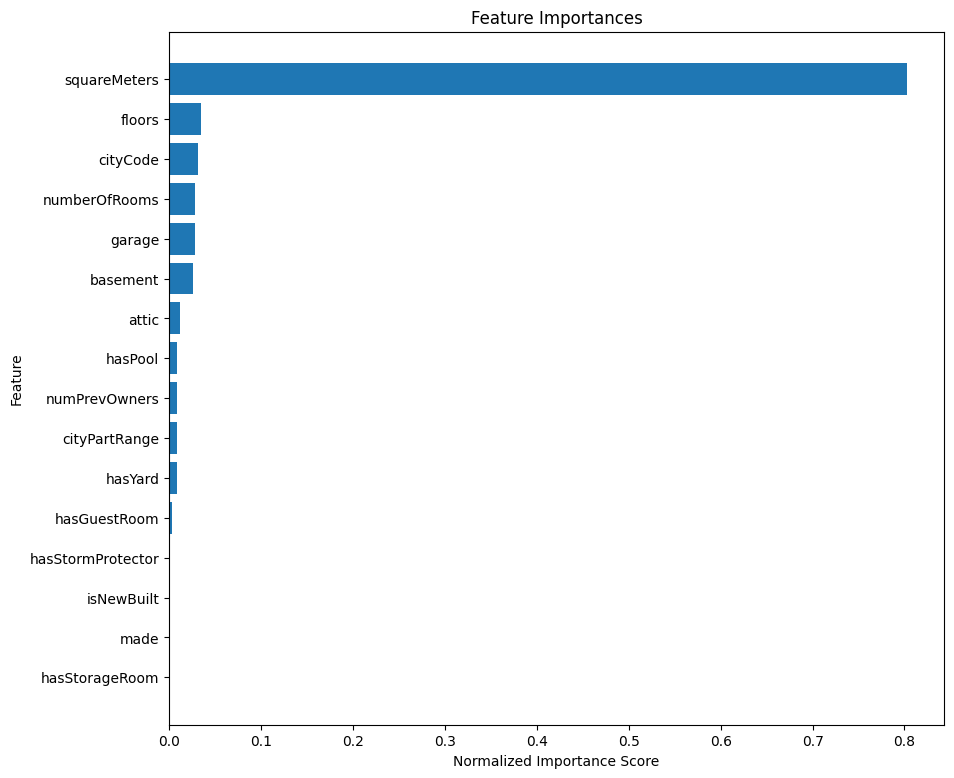

,Feature,Importance
0,squareMeters,0.802857
4,floors,0.034286
5,cityCode,0.031429
1,numberOfRooms,0.028571
13,garage,0.028571
11,basement,0.025714
12,attic,0.011429
3,hasPool,0.008571
7,numPrevOwners,0.008571
6,cityPartRange,0.008571


In [ ]:
import matplotlib.pyplot as plt

importances = best_lgb_model.feature_importances_


importances = importances / importances.sum()

importance_df = pd.DataFrame({
        'Feature':  x_train.columns,
        'Importance': importances
    }).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 9))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title("Feature Importances")
plt.xlabel("Normalized Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()
importance_df

In [ ]:
# Extract features with importance between 1%-35%
important_features_df = importance_df[(importance_df['Importance'] > 0.01) & (importance_df['Importance'] < 0.35)]

print("Features with Importance 1%:")
important_features_df

Features with Importance 1%:


,Feature,Importance
4,floors,0.034286
5,cityCode,0.031429
1,numberOfRooms,0.028571
13,garage,0.028571
11,basement,0.025714
12,attic,0.011429


## SHAP Analysis — Selected Features

In [ ]:
pip install shap

In [ ]:
import shap

Shap Values Summary (Selected Feature)


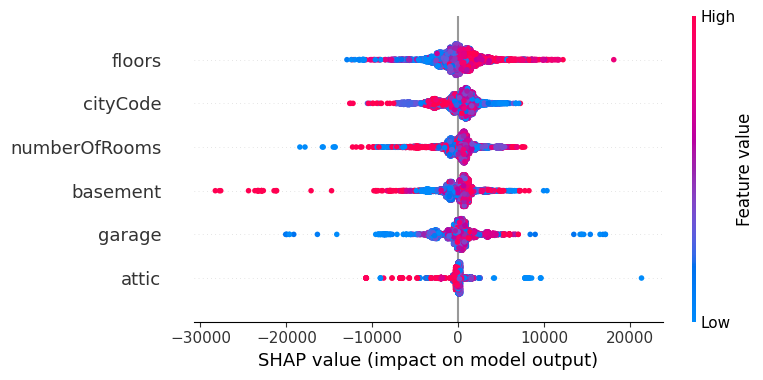

In [ ]:
selected_feature = important_features_df.Feature.tolist()
explainer = shap.TreeExplainer(best_lgb_model)
shap_values = explainer.shap_values(x_train)

shap_df = pd.DataFrame(shap_values, columns=x_train.columns)
shap_selected = shap_df[selected_feature]
x_selected = x_train[selected_feature]

print("Shap Values Summary (Selected Feature)")
plt.figure(figsize=(10,6))
shap.summary_plot(shap_selected.values, x_selected,show=False)
plt.tight_layout()
plt.show()


## Final Model — LightGBM on Selected Features

In [ ]:
new_inputs = important_features_df.Feature.tolist()
new_inputs

['floors', 'cityCode', 'numberOfRooms', 'garage', 'basement', 'attic']

In [ ]:
fin_input = data[important_features_df['Feature'].tolist()]
fin_output = data['price']
x_train_fin, x_test_fin,y_train_fin, y_test_fin = train_test_split(fin_input,fin_output, test_size=0.2, random_state=42)

In [ ]:
def best_params_for_model(trial):
  param = {
      'n_estimators': trial.suggest_int('n_estimators', 100,10000),
      'learning_rate': trial.suggest_float('learning_rate', 0.01,1.0, log=True),
      'max_depth': trial.suggest_int('max_depth', 3,12),
      'num_leaves': trial.suggest_int('num_leaves', 5,8)
  }

  lgb_reg = LGBMRegressor(**param)
  r2 = cross_val_score(lgb_reg, x_train_fin, y_train_fin, cv=5, scoring='r2', n_jobs=-1).mean()
  return r2

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=10)

print('Best trial')
best_params= study.best_params
print(' Value: {:.3f}'.format(study.best_value))
print(' Params:', best_params)

best_lgb_model_fin = LGBMRegressor(**best_params,random_state=42)

[I 2026-04-22 13:11:24,451] A new study created in memory with name: no-name-9ee33a3b-0e62-480d-b674-62886eaf12d8
[I 2026-04-22 13:11:34,038] Trial 0 finished with value: -0.5404959167447814 and parameters: {'n_estimators': 2285, 'learning_rate': 0.5694414389940017, 'max_depth': 12, 'num_leaves': 8}. Best is trial 0 with value: -0.5404959167447814.
[I 2026-04-22 13:11:44,900] Trial 1 finished with value: -0.40011295077319564 and parameters: {'n_estimators': 4505, 'learning_rate': 0.19674388798893913, 'max_depth': 3, 'num_leaves': 8}. Best is trial 1 with value: -0.40011295077319564.
[I 2026-04-22 13:11:45,653] Trial 2 finished with value: -0.3015173264728907 and parameters: {'n_estimators': 485, 'learning_rate': 0.6362444963599632, 'max_depth': 4, 'num_leaves': 6}. Best is trial 2 with value: -0.3015173264728907.
[I 2026-04-22 13:11:51,168] Trial 3 finished with value: -0.04605729919568731 and parameters: {'n_estimators': 3073, 'learning_rate': 0.01645442497317208, 'max_depth': 12, 'nu

Best trial
 Value: -0.046
 Params: {'n_estimators': 3073, 'learning_rate': 0.01645442497317208, 'max_depth': 12, 'num_leaves': 7}


In [ ]:
result = train_and_evaluate_model('LightGBM optimized for selected features', best_lgb_model_fin, x_train_fin, y_train_fin, x_test_fin, y_test_fin)
result

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000675 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1221
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 6
[LightGBM] [Info] Start training from score 4964091.744861
Model Performance for LightGBM optimized for selected features
[TRAIN]  R²: 0.2182 | MAE: 2156554.6958 | RMSE: 2524845.2519
Model Performance for LightGBM optimized for selected features
  [TEST] R²: -0.0463 | MAE: 2620781.6066 | RMSE: 3027216.5196


[0.21823545817011536, -0.046271846703472175]